N= 2, τ=0.4808, Eb=1.190632, Ergotropy=1.029524, erg/Eb=0.864686352329 Variance=8.2259464545e-01
N= 3, τ=0.5060, Eb=1.908804, Ergotropy=1.739145, erg/Eb=0.911117513418 Variance=1.2453818951e+00
N= 4, τ=0.5206, Eb=2.645386, Ergotropy=2.470733, erg/Eb=0.933978321874 Variance=1.6549355891e+00
N= 5, τ=0.5303, Eb=3.392296, Ergotropy=3.214302, erg/Eb=0.947530124049 Variance=2.0548315175e+00
N= 6, τ=0.5371, Eb=4.144388, Ergotropy=3.964055, erg/Eb=0.956487470104 Variance=2.4478686379e+00
N= 7, τ=0.5422, Eb=4.900310, Ergotropy=4.718218, erg/Eb=0.962840746023 Variance=2.8358777741e+00
N= 8, τ=0.5461, Eb=5.658156, Ergotropy=5.474723, erg/Eb=0.967580687632 Variance=3.2203554382e+00
N= 9, τ=0.5493, Eb=6.418688, Ergotropy=6.234145, erg/Eb=0.971249177173 Variance=3.6016964324e+00


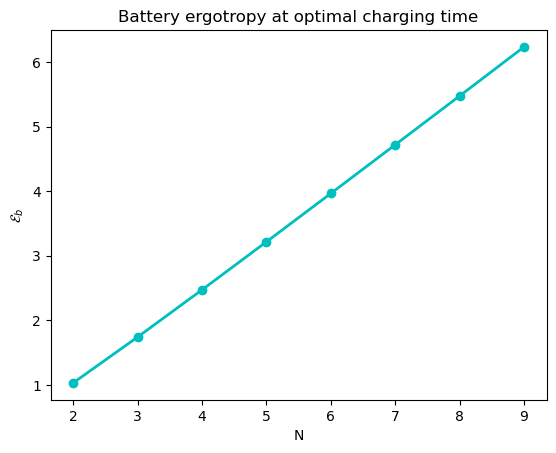

In [5]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 10, 1)
nmax  = 60
ω = ω0 = g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Dicke Hamiltonian
#############################

def dicke_fun(N, nmax, ω, ω0, g):

    # Bosonic mode:
    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)
   
    # Spin-1/2 operators:
    jp, jm, jz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    # Embed single-spin operator into N-spin Hilbert space
    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Jp = sum(embed(jp, i) for i in range(N))
    Jm = Jp.dag()
    Jz = 0.5 * sum(embed(jz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Jz + 0.5 * N * IB
    

    H = ω  * qt.tensor(a.dag() * a, IB) + ω0 * qt.tensor(Ic, HB) + g * (1.0 / np.sqrt(N) * qt.tensor(a + a.dag(), Jp + Jm))
    
    return H, HB


##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = dicke_fun(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full, options=opts)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = dicke_fun(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(list(range(1, N+1)))

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

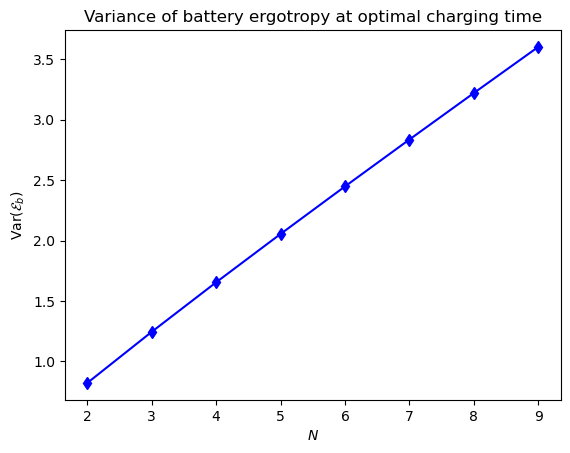

In [6]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

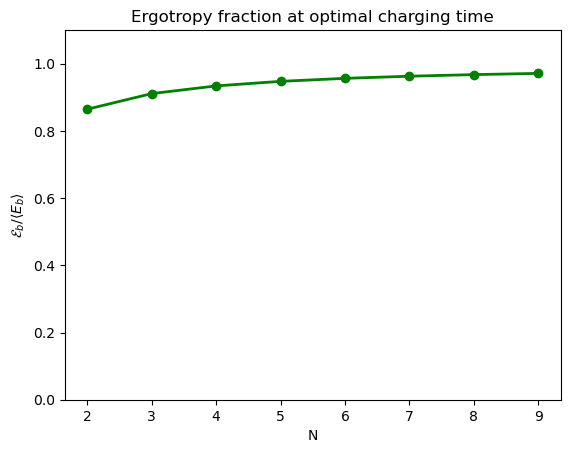

In [7]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("OP3")
plt.show()

N= 2, τ=0.4808, Relative Fluctuation =0.880960936870, Relative Fluctuation with Eb =0.761754899046
N= 3, τ=0.5060, Relative Fluctuation =0.641675700248, Relative Fluctuation with Eb =0.584641968431
N= 4, τ=0.5206, Relative Fluctuation =0.520672587276, Relative Fluctuation with Eb =0.486296909310
N= 5, τ=0.5303, Relative Fluctuation =0.445965614811, Relative Fluctuation with Eb =0.422565854323
N= 6, τ=0.5371, Relative Fluctuation =0.394688433084, Relative Fluctuation with Eb =0.377514540840
N= 7, τ=0.5422, Relative Fluctuation =0.356915807194, Relative Fluctuation with Eb =0.343653082066
N= 8, τ=0.5461, Relative Fluctuation =0.327785534475, Relative Fluctuation with Eb =0.317158952843
N= 9, τ=0.5493, Relative Fluctuation =0.304422430073, Relative Fluctuation with Eb =0.295670034721


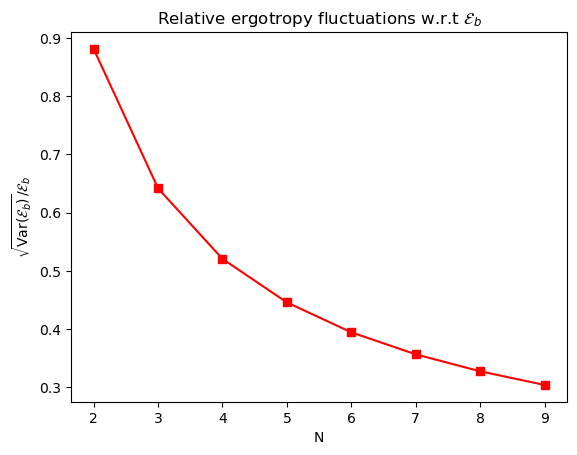

In [8]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
#plt.savefig("OP4")
plt.show()

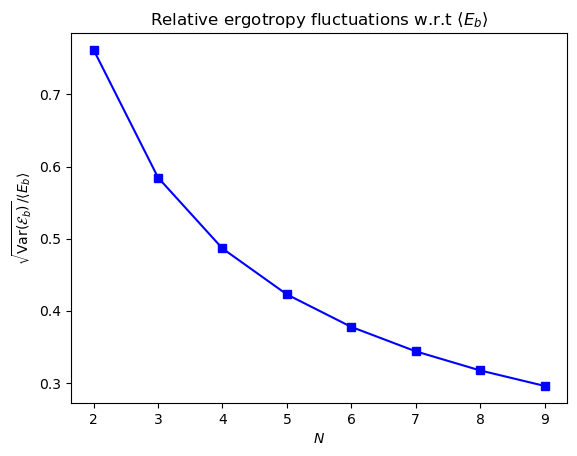

In [9]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("OP5")
plt.show()